
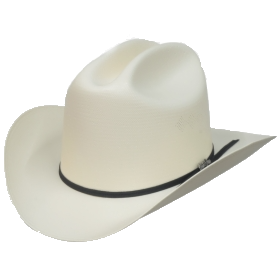
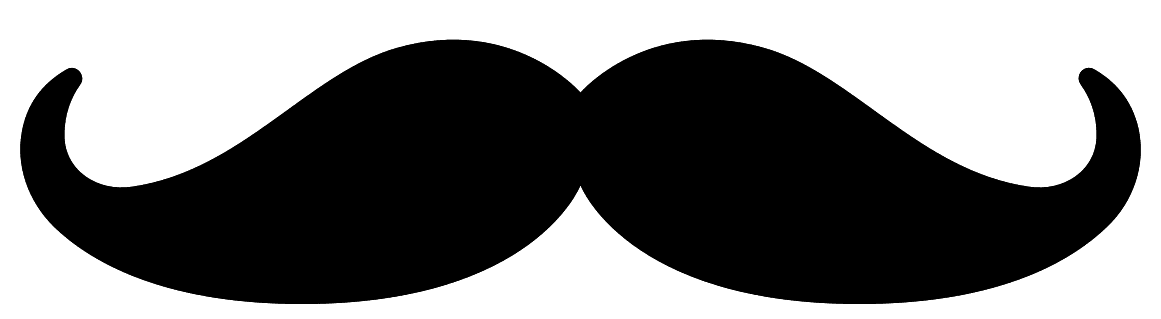
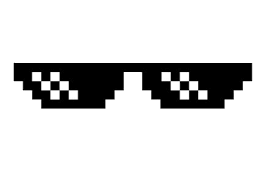
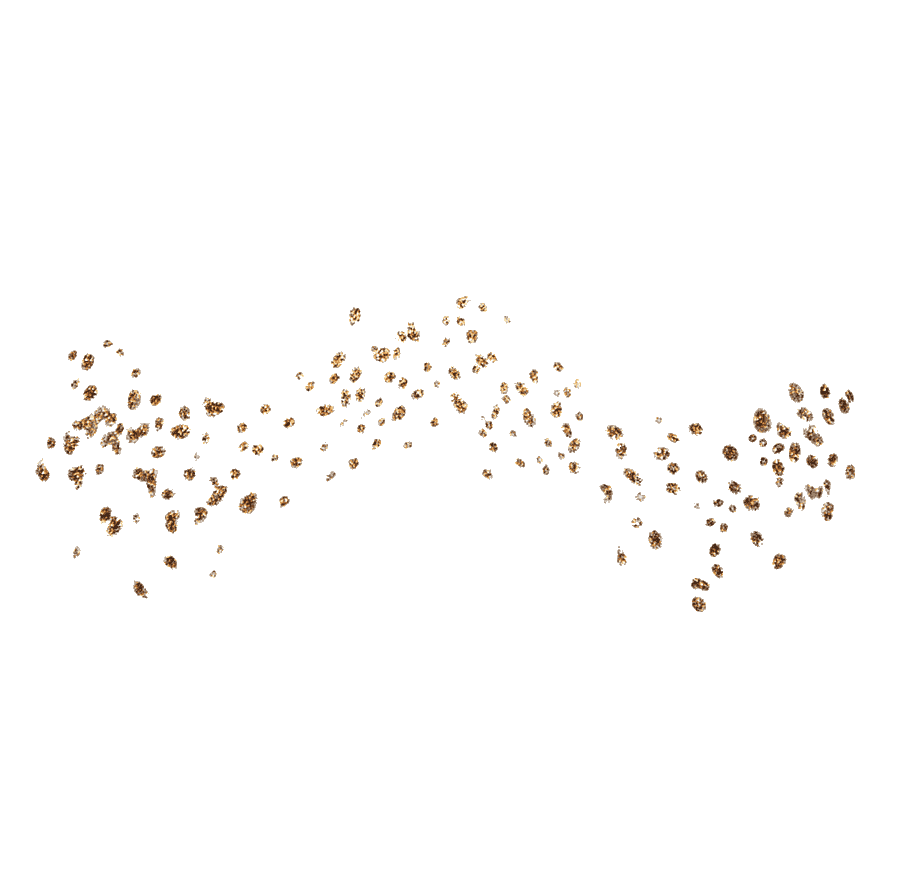

In [22]:
import cv2
import base64
from IPython.display import HTML

# --- 1. PREPARACIÓN DE RECURSOS ---
def img_to_b64(path):
    try:
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        _, buffer = cv2.imencode('.png', img)
        return "data:image/png;base64," + base64.b64encode(buffer).decode()
    except: return ""

# Cargamos tus archivos
lentes_data = img_to_b64('Lentes.png')
bigote_data = img_to_b64('mustache.png')
pecas_data = img_to_b64('pecas.png')
sombrero_data = img_to_b64('sombrero.png')

# --- 2. INTERFAZ Y FILTROS MATEMÁTICOS ---
HTML(f"""
<div style="display: flex; flex-direction: column; align-items: center; background: #2c3e50; padding: 20px; border-radius: 15px; font-family: sans-serif;">
    <h3 style="color: white; margin-bottom: 15px;">Métodos Numéricos: Gradientes y Filtros</h3>

    <div style="margin-bottom: 15px; display: flex; gap: 8px; flex-wrap: wrap; justify-content: center;">
        <button onclick="toggle('sombrero')" style="padding: 8px 15px; border-radius: 5px; cursor: pointer;">Sombrero</button>
        <button onclick="toggle('bigote')" style="padding: 8px 15px; border-radius: 5px; cursor: pointer;">Bigote</button>
        <button onclick="toggle('lentes')" style="padding: 8px 15px; border-radius: 5px; cursor: pointer;">Lentes</button>
        <button onclick="toggle('pecas')" style="padding: 8px 15px; border-radius: 5px; cursor: pointer;">Pecas</button>
        <button onclick="toggle('grises')" style="padding: 8px 15px; border-radius: 5px; cursor: pointer; background: #7f8c8d; color: white;">Escala de Grises</button>
        <button onclick="toggle('malla')" style="padding: 8px 15px; border-radius: 5px; cursor: pointer; background: #3498db; color: white;">Ver Malla (Derivadas)</button>
        <button onclick="limpiarTodo()" style="padding: 8px 15px; border-radius: 5px; cursor: pointer; background: #e74c3c; color: white;">Reset</button>
    </div>

    <div style="position: relative; width: 640px; height: 480px;">
        <video id="webcam" width="640" height="480" autoplay playsinline style="display:none;"></video>
        <canvas id="output" width="640" height="480" style="border-radius: 10px; transform: scaleX(-1); box-shadow: 0 10px 30px rgba(0,0,0,0.5);"></canvas>
    </div>
</div>

<script src="https://cdn.jsdelivr.net/npm/@mediapipe/face_mesh"></script>
<script src="https://cdn.jsdelivr.net/npm/@mediapipe/camera_utils"></script>
<script src="https://cdn.jsdelivr.net/npm/@mediapipe/drawing_utils"></script>

<script>
    const video = document.getElementById('webcam');
    const canvas = document.getElementById('output');
    const ctx = canvas.getContext('2d');

    let activo = {{ sombrero: false, bigote: false, lentes: false, pecas: false, malla: true, grises: false }};

    const imgs = {{
        sombrero: new Image(), bigote: new Image(), lentes: new Image(), pecas: new Image()
    }};
    imgs.sombrero.src = "{sombrero_data}";
    imgs.bigote.src = "{bigote_data}";
    imgs.lentes.src = "{lentes_data}";
    imgs.pecas.src = "{pecas_data}";

    function toggle(f) {{ activo[f] = !activo[f]; }}
    function limpiarTodo() {{ Object.keys(activo).forEach(k => activo[k] = false); }}

    const faceMesh = new FaceMesh({{locateFile: (file) => `https://cdn.jsdelivr.net/npm/@mediapipe/face_mesh/${{file}}` }});
    faceMesh.setOptions({{ maxNumFaces: 1, refineLandmarks: true, minDetectionConfidence: 0.5 }});

    faceMesh.onResults((results) => {{
        ctx.save();
        ctx.clearRect(0, 0, canvas.width, canvas.height);

        // DIBUJAR VIDEO (CON O SIN GRISES)
        ctx.drawImage(results.image, 0, 0, canvas.width, canvas.height);

        if (activo.grises) {{
            let imageData = ctx.getImageData(0, 0, canvas.width, canvas.height);
            let d = imageData.data;
            for (let i = 0; i < d.length; i += 4) {{
                let avg = (d[i] + d[i+1] + d[i+2]) / 3;
                d[i] = d[i+1] = d[i+2] = avg;
            }}
            ctx.putImageData(imageData, 0, 0);
        }}

        if (results.multiFaceLandmarks) {{
            for (const landmarks of results.multiFaceLandmarks) {{
                const fw = Math.abs(landmarks[234].x - landmarks[454].x) * canvas.width;

                if (activo.malla) {{
                    drawConnectors(ctx, landmarks, FACEMESH_TESSELATION, {{color: '#FFFFFF40', lineWidth: 1}});
                }}

                // Superposición de Accesorios
                if (activo.sombrero) ctx.drawImage(imgs.sombrero, landmarks[10].x * canvas.width - (fw * 0.6), landmarks[10].y * canvas.height - (fw * 0.9), fw * 1.2, fw * 0.8);
                if (activo.lentes) ctx.drawImage(imgs.lentes, landmarks[168].x * canvas.width - (fw * 0.45), landmarks[168].y * canvas.height - (fw * 0.2), fw * 0.9, fw * 0.4);
                if (activo.bigote) ctx.drawImage(imgs.bigote, landmarks[164].x * canvas.width - (fw * 0.25), landmarks[164].y * canvas.height, fw * 0.5, fw * 0.2);
                if (activo.pecas) ctx.drawImage(imgs.pecas, landmarks[168].x * canvas.width - (fw * 0.4), landmarks[168].y * canvas.height, fw * 0.8, fw * 0.3);
            }}
        }}
        ctx.restore();
    }});

    new Camera(video, {{ onFrame: async () => {{ await faceMesh.send({{image: video}}); }}, width: 640, height: 480 }}).start();
</script>
""")